In [1]:
import os
import sys

# Проверяем, запущен ли ноутбук в среде Google Colab
if "google.colab" in sys.modules:
    !pip install uv -q
    !wget https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/pyproject.toml -q
    !uv pip install -r pyproject.toml --system -q
    os.kill(os.getpid(), 9)  # force runtime restart

# Семинар 2 · Ноутбук 1
# Стратегии кросс-валидации для временных рядов

Кросс-валидация во временных рядах устроена иначе, чем в обычном ML. **Данные нельзя перемешивать**: если тест окажется «в прошлом» относительно обучения, модель фактически заглянет в будущее — возникнет утечка (data leakage), и оценка качества будет завышенной. Ниже мы сначала увидим эту утечку на цифрах, потом разберём минимальное исправление, а затем — как одна и та же идея walk-forward выражается в интерфейсах трёх специализированных библиотек.

## Что мы разберём

| Раздел | Вопрос, на который отвечаем |
|---|---|
| 1 | Почему `train_test_split` и `KFold` из обычного ML дают завышенную оценку качества на рядах? |
| 2 | Как исправить это минимально — `TimeSeriesSplit` из scikit-learn? |
| 3 | Как `sktime` описывает окна обучения/прогноза как объекты-сплиттеры и оценивает модель через `evaluate`? |
| 4 | Как `StatsForecast` упаковывает весь walk-forward в один вызов `cross_validation`? |
| 5 | Как `ETNA` организует бэктест через `Pipeline.backtest` и маски фолдов? |


---
## 1. Антипример: случайное разбиение и `KFold`

Стандартный приём в ML — перемешать данные и случайно отрезать часть под валидацию (`train_test_split`, `KFold(shuffle=True)`). Для временных рядов это **ломает временной порядок**: модель обучается на будущих наблюдениях и «предсказывает» прошлое. Ряды сериально коррелированы, поэтому соседние точки почти дублируют друг друга — валидация оказывается «слишком лёгкой», и оценка качества завышается.

Проверим это на практике на дневных котировках `GOOGL`. Сведём прогноз к обычной ML-задаче на лаговых признаках и обучим `RandomForestRegressor`. Последние 40 торговых дней отложим как **честный «будущий» тест** — то, что модель реально встретит в проде. Качество на валидации оценим двумя способами и сравним с честной ошибкой на будущем.

In [2]:
from warnings import simplefilter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, r2_score
from sklearn.model_selection import KFold, TimeSeriesSplit, train_test_split

simplefilter("ignore")
plt.rcParams["figure.figsize"] = (11, 3)
RANDOM_STATE = 13

Загрузим ряд. Индекс приводим к рабочим дням (`asfreq("B")`) — так пропуски в котировках (праздники, сбои) не выпадают из сетки, а заполняются последним известным значением.

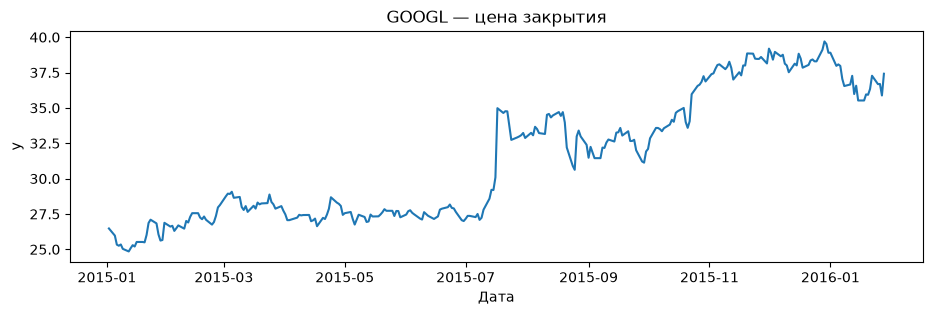

In [3]:
googl = (
    pd.read_csv(
        "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/data/GOOGL.csv",
        parse_dates=["Date"],
    )
    .set_index("Date")["Close"]
    .asfreq("B")
    .ffill()
)

fig, ax = plt.subplots()
ax.plot(googl.index, googl)
ax.set(title="GOOGL — цена закрытия", xlabel="Дата", ylabel="y")
plt.show()

Превратим ряд в таблицу «признаки → цель». Ключевой момент: прогнозируем не «завтра», а **на 20 торговых дней вперёд** (`HORIZON = 20`) — типичная практическая постановка («что будет через месяц»). Поэтому лаги берём не `1..10`, а `20..29`: на момент прогноза последние 19 значений ряда ещё неизвестны.

🔍 Если бы мы прогнозировали на 1 шаг вперёд, лаг `y_{t-1}` почти совпадает с `y_t` (котировки меняются плавно) — задача выродится в «повтори вчерашнее значение», и разница между схемами валидации станет незаметной. Горизонт `h=20` — то, что делает утечку видимой.

In [4]:
HORIZON = 20
N_LAGS = 10
TEST_SIZE = 40


def make_lagged(series, n_lags=N_LAGS, horizon=HORIZON):
    """Строит лаговые признаки lag_h..lag_(h+n_lags-1) и номер месяца."""
    df = pd.DataFrame({"y": series})
    for L in range(horizon, horizon + n_lags):
        df[f"lag_{L}"] = df["y"].shift(L)
    df["month"] = df.index.month
    return df.dropna()


data = make_lagged(googl)
X, y = data.drop(columns="y"), data["y"]

# последние 40 торговых дней — честный «будущий» тест
X_pool, X_test = X.iloc[:-TEST_SIZE], X.iloc[-TEST_SIZE:]
y_pool, y_test = y.iloc[:-TEST_SIZE], y.iloc[-TEST_SIZE:]

# эталон: обучаемся на всём пуле и смотрим реальную ошибку на будущем тесте
ref = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE).fit(X_pool, y_pool)
future_mape = mean_absolute_percentage_error(y_test, ref.predict(X_test))
print(f"Честная ошибка на будущем тесте: MAPE = {future_mape:.1%}")

Честная ошибка на будущем тесте: MAPE = 12.4%


### Случайное разбиение

Отрежем 25 % пула случайно. Посмотрим на две цифры: ошибку на такой валидации и ошибку той же модели на честном будущем тесте.

In [5]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_pool, y_pool, test_size=0.25, random_state=RANDOM_STATE
)

model = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE).fit(X_tr, y_tr)
random_val_mape = mean_absolute_percentage_error(y_val, model.predict(X_val))

print("Случайное разбиение")
print(
    f"  валидация:    MAPE = {random_val_mape:.1%}   R2 = {r2_score(y_val, model.predict(X_val)):.2f}"
)
print(
    f"  будущий тест: MAPE = {mean_absolute_percentage_error(y_test, model.predict(X_test)):.1%}   "
    f"R2 = {r2_score(y_test, model.predict(X_test)):.2f}"
)

Случайное разбиение
  валидация:    MAPE = 2.3%   R2 = 0.93
  будущий тест: MAPE = 12.3%   R2 = -28.73


  валидация:    MAPE = 2.3%   R2 = 0.93
  будущий тест: MAPE = 12.3%   R2 = -28.73


Валидация выглядит прекрасно ($R^2 \approx 0.93$), а на реальном будущем тот же обученный лес не просто ошибается — $R^2$ уходит в глубокий минус: модель систематически хуже, чем константа. Разрыв в **5 раз** по MAPE. Причина видна на картинке: случайные точки валидации **перемешаны с обучающими** во времени — для каждой из них рядом есть почти такой же сосед из train, и предсказать её легко.

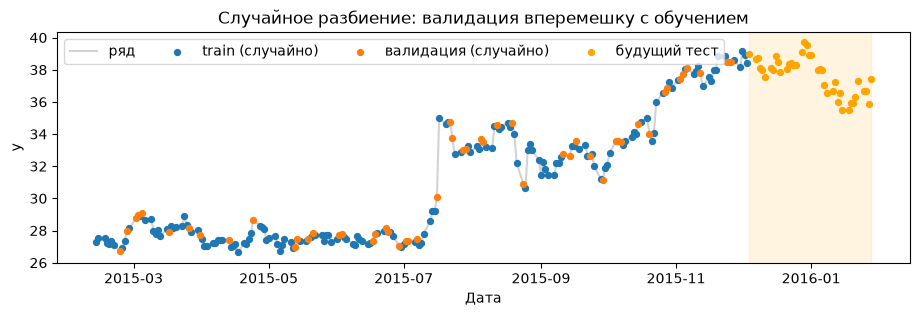

In [6]:
fig, ax = plt.subplots()
ax.plot(y_pool.index, y_pool, color="lightgray", zorder=1, label="ряд")
ax.scatter(X_tr.index, y_tr, s=18, label="train (случайно)")
ax.scatter(X_val.index, y_val, s=18, label="валидация (случайно)")
ax.scatter(X_test.index, y_test, s=18, color="orange", label="будущий тест")
ax.axvspan(X_test.index[0], X_test.index[-1], color="orange", alpha=0.12)
ax.legend(ncol=4, loc="upper left")
ax.set(title="Случайное разбиение: валидация вперемешку с обучением", xlabel="Дата", ylabel="y")
plt.show()

Три проблемы на этой картинке — они же причины завышенной оценки:

- **тест раньше трейна** — часть валидационных точек хронологически предшествует части обучающих;
- **дыры в обучающем ряду** — вычеркнутые под валидацию точки разрывают историю;
- **соседи по времени в разных выборках** — при горизонте 20 и 10 лагах соседние наблюдения `t` и `t+1` почти полностью делят набор признаков, так что валидационная точка фактически «уже видена» моделью через почти идентичного соседа в train.

### `KFold(shuffle=True)`

`KFold` с перемешиванием — та же беда, только повторённая по фолдам: тест регулярно оказывается раньше обучения, а в обучающем ряду появляются «дыры».

In [7]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = []
for tr_idx, val_idx in kf.split(X_pool):
    m = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
    m.fit(X_pool.iloc[tr_idx], y_pool.iloc[tr_idx])
    scores.append(
        mean_absolute_percentage_error(y_pool.iloc[val_idx], m.predict(X_pool.iloc[val_idx]))
    )

kfold_val_mape = float(np.mean(scores))
print(f"KFold(shuffle=True): средний MAPE по фолдам = {kfold_val_mape:.1%}")

KFold(shuffle=True): средний MAPE по фолдам = 2.1%


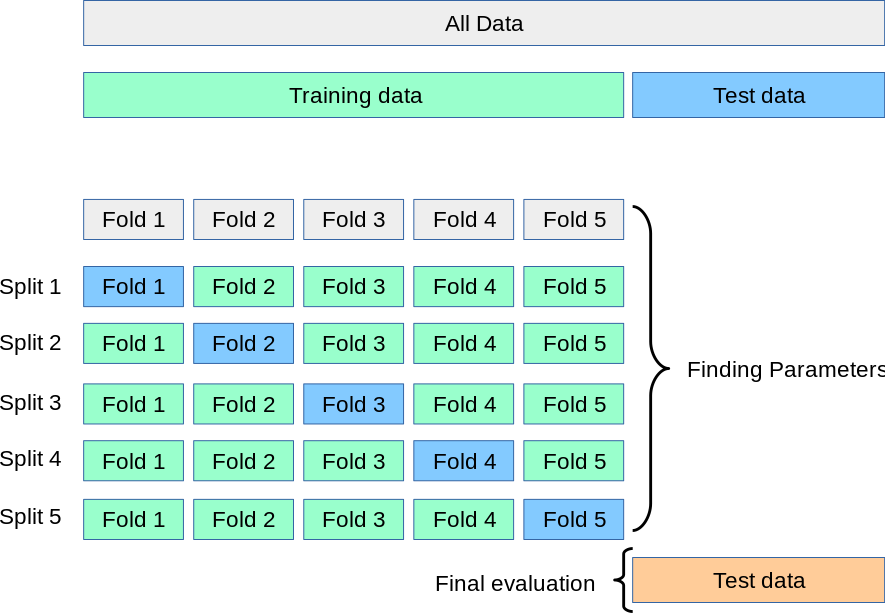

Оба метода дают оценку MAPE в разы ниже честной ошибки на будущем тесте.


---
## 2. Минимальное исправление: `TimeSeriesSplit`

Правильная идея — **делить по шкале времени**: обучение всегда раньше валидации, тест «едет» вперёд. Так мы не заглядываем в будущее.

`TimeSeriesSplit` из scikit-learn реализует это напрямую: в $k$-м фолде первые $k$ блоков идут в обучение, $(k{+}1)$-й — в валидацию. Обучающая часть либо растёт (по умолчанию), либо имеет фиксированный размер (`max_train_size`).

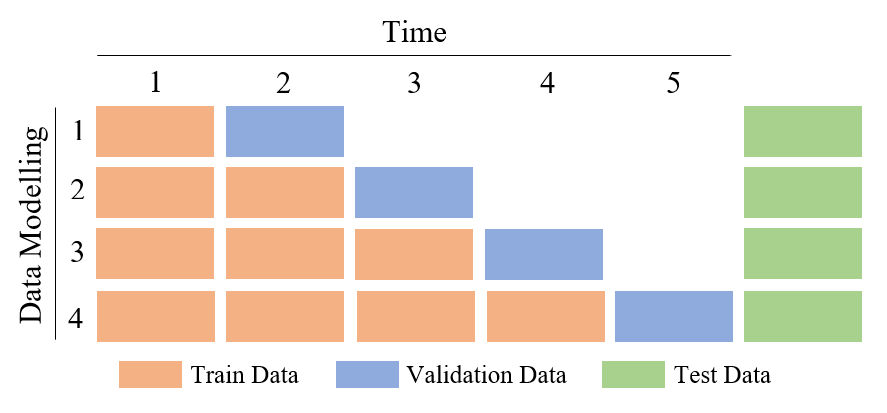

Как это выглядит на индексах (расширяющееся обучающее окно):

In [8]:
tscv = TimeSeriesSplit(n_splits=5)
for i, (tr_idx, val_idx) in enumerate(tscv.split(np.arange(20))):
    print(f"fold {i}:  train={tr_idx}  test={val_idx}")

fold 0:  train=[0 1 2 3 4]  test=[5 6 7]
fold 1:  train=[0 1 2 3 4 5 6 7]  test=[ 8  9 10]
fold 2:  train=[ 0  1  2  3  4  5  6  7  8  9 10]  test=[11 12 13]
fold 3:  train=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]  test=[14 15 16]
fold 4:  train=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]  test=[17 18 19]


С `max_train_size` обучающее окно становится **скользящим** фиксированной длины — удобно, когда далёкое прошлое уже не релевантно.

In [9]:
tscv = TimeSeriesSplit(n_splits=5, max_train_size=6)
for i, (tr_idx, val_idx) in enumerate(tscv.split(np.arange(20))):
    print(f"fold {i}:  train={tr_idx}  test={val_idx}")

fold 0:  train=[0 1 2 3 4]  test=[5 6 7]
fold 1:  train=[2 3 4 5 6 7]  test=[ 8  9 10]
fold 2:  train=[ 5  6  7  8  9 10]  test=[11 12 13]
fold 3:  train=[ 8  9 10 11 12 13]  test=[14 15 16]
fold 4:  train=[11 12 13 14 15 16]  test=[17 18 19]


🔍 Есть ещё один аргумент, о котором легко забыть при прогнозе на горизонт `h > 1`: **`gap`**. Мы прогнозируем на `HORIZON = 20` дней вперёд, а значит признаки последней обучающей точки построены по значениям, которые пересекаются по времени с первыми тестовыми точками. Без зазора `TimeSeriesSplit` подсовывает почти те же соседние наблюдения, что и в антипримере выше — только не случайно, а на стыке фолдов. Лечится параметром `gap=h-1`: он выбрасывает `h-1` наблюдений между train и test.

In [11]:
tscv_gap = TimeSeriesSplit(n_splits=5, gap=HORIZON - 1)
for i, (tr_idx, val_idx) in enumerate(tscv_gap.split(np.arange(100))):
    print(f"fold {i}:  train={tr_idx}  test={val_idx}")

fold 0:  train=[0]  test=[20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35]
fold 1:  train=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]  test=[36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51]
fold 2:  train=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32]  test=[52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67]
fold 3:  train=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48]  test=[68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83]
fold 4:  train=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64]  test=[84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99]


Оценим ту же `RandomForest` на `GOOGL` через `TimeSeriesSplit` — с зазором и без.

In [12]:
def tss_mape(cv):
    scores = []
    for tr_idx, val_idx in cv.split(X_pool):
        m = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
        m.fit(X_pool.iloc[tr_idx], y_pool.iloc[tr_idx])
        scores.append(
            mean_absolute_percentage_error(y_pool.iloc[val_idx], m.predict(X_pool.iloc[val_idx]))
        )
    return float(np.mean(scores))


tss_val_mape = tss_mape(TimeSeriesSplit(n_splits=5))
tss_gap_val_mape = tss_mape(TimeSeriesSplit(n_splits=5, gap=HORIZON - 1))
print(f"TimeSeriesSplit:            средний MAPE = {tss_val_mape:.1%}")
print(f"TimeSeriesSplit(gap=h-1):   средний MAPE = {tss_gap_val_mape:.1%}")

TimeSeriesSplit:            средний MAPE = 6.9%
TimeSeriesSplit(gap=h-1):   средний MAPE = 7.8%


Сравним, что каждая схема «обещает» на валидации, с честной ошибкой на будущем тесте.

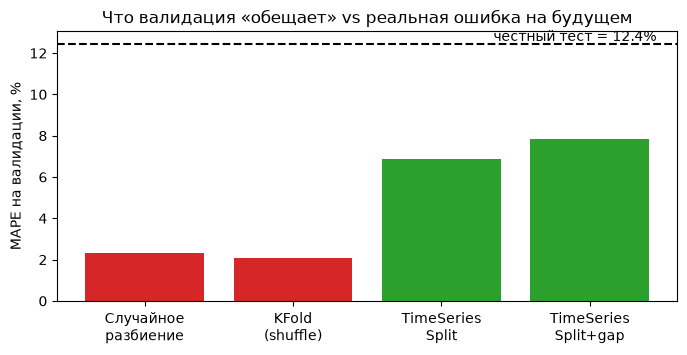

In [13]:
estimates = {
    "Случайное\nразбиение": 100 * random_val_mape,
    "KFold\n(shuffle)": 100 * kfold_val_mape,
    "TimeSeries\nSplit": 100 * tss_val_mape,
    "TimeSeries\nSplit+gap": 100 * tss_gap_val_mape,
}
colors = ["#d62728", "#d62728", "#2ca02c", "#2ca02c"]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(list(estimates), list(estimates.values()), color=colors)
ax.axhline(100 * future_mape, ls="--", color="black")
ax.text(3.45, 100 * future_mape, f"честный тест = {future_mape:.1%}", va="bottom", ha="right")
ax.set(ylabel="MAPE на валидации, %", title="Что валидация «обещает» vs реальная ошибка на будущем")
plt.show()

`TimeSeriesSplit` заметно ближе к честному тесту, чем случайное разбиение или `KFold`, но обе его версии всё ещё оптимистичнее реальности: ранние фолды приходятся на более спокойный период котировок, а сам ряд впереди становится «сложнее». Так и должно быть — **никакая валидация не заменяет честный отложенный тест**, но walk-forward хотя бы не врёт систематически в одну сторону из-за утечки. `gap` слегка увеличивает оценку MAPE — она стала чуть менее оптимистичной, потому что модель больше не подсматривает соседние по времени точки на стыке фолдов.

---
## 3. `sktime`: сплиттеры окон и `evaluate`

`TimeSeriesSplit` покрывает базовый walk-forward, но у `sktime` есть более гибкий набор сплиттеров из `sktime.split`. Они порождают серии окон «обучение → горизонт прогноза», которые удобно визуализировать, а функция `evaluate` сама прогоняет через них модель — как раньше мы делали циклом вручную. Разберём их на первых 30 точках ряда `a10`, чтобы окна были видны на графике.

In [41]:
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.model_evaluation import evaluate
from sktime.forecasting.naive import NaiveForecaster
from sktime.split import (
    CutoffSplitter,
    ExpandingWindowSplitter,
    SingleWindowSplitter,
    SlidingWindowSplitter,
    temporal_train_test_split,
)
from sktime.utils.plotting import plot_series, plot_windows

Загрузим `a10` заново и приведём индекс к месячному `PeriodIndex` — так его понимают сплиттеры `sktime`.

In [42]:
a10 = (
    pd.read_csv(
        "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/data/a10.csv",
        parse_dates=["Month"],
    )
    .rename(columns={"Cost": "y"})
    .set_index("Month")["y"]
)
a10.index = a10.index.to_period("M")

Вспомогательная функция для визуализации окон: серым — весь ряд, синим — обучающее окно, оранжевым — горизонт прогноза.

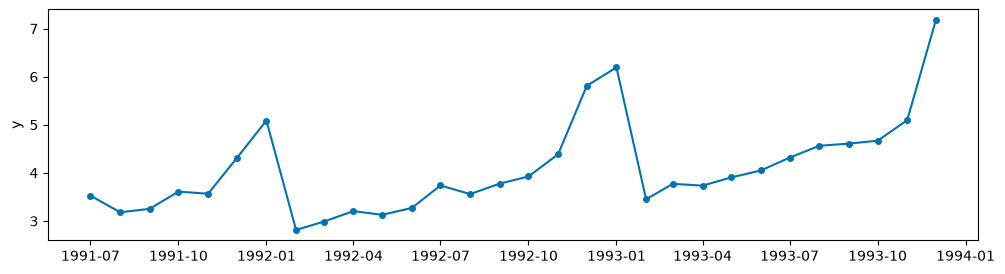

In [49]:
y = a10.iloc[:30]
fig, ax = plot_series(y)

### Однократное разбиение — `temporal_train_test_split`

Простейший случай: один раз делим ряд на обучение и тест. Размер теста можно задать долей (`test_size`) либо через горизонт прогноза (`fh`).

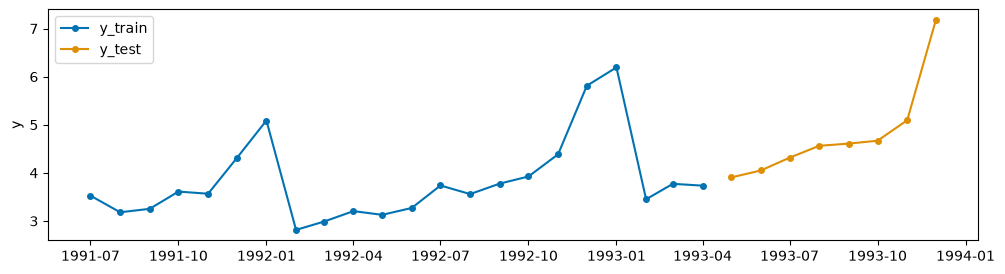

In [50]:
y_train, y_test = temporal_train_test_split(y=y, test_size=0.25)
fig, ax = plot_series(y_train, y_test, labels=["y_train", "y_test"])

(<Figure size 1200x300 with 1 Axes>, <Axes: ylabel='y'>)

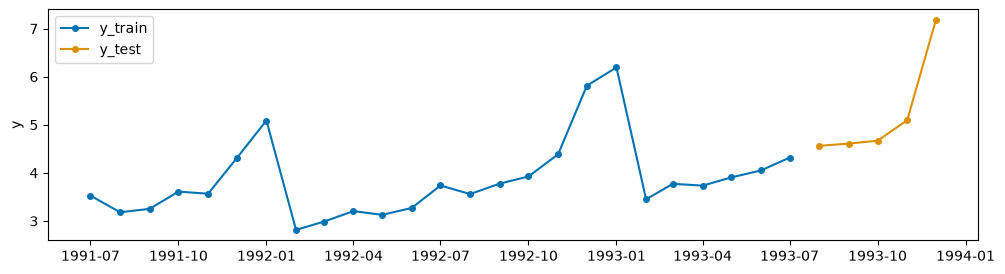

In [51]:
fh = ForecastingHorizon([1, 2, 3, 4, 5])
y_train, y_test = temporal_train_test_split(y, fh=fh)
plot_series(y_train, y_test, labels=["y_train", "y_test"])

### `SingleWindowSplitter`

Одно разбиение на окно фиксированной длины и горизонт — по сути то же, что выше, но в виде сплиттера с методом `split`.

Число фолдов = 1


(<Figure size 1000x300 with 1 Axes>,
 <Axes: xlabel='Time', ylabel='Window number'>)

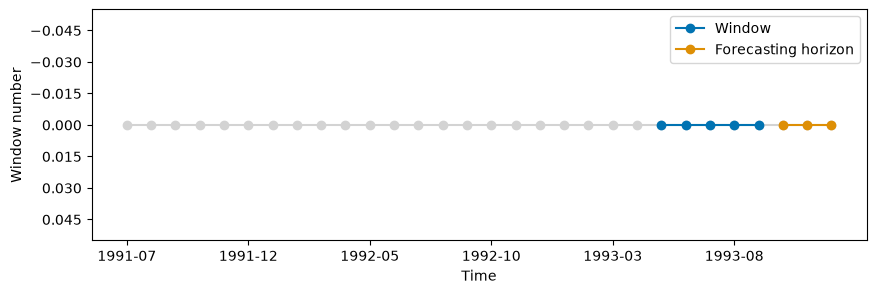

In [54]:
window_length = 5
fh = ForecastingHorizon([1, 2, 3])

cv = SingleWindowSplitter(window_length=window_length, fh=fh)
print(f"Число фолдов = {cv.get_n_splits(y)}")
plot_windows(cv, y)

### `SlidingWindowSplitter` — скользящее окно

Фолды двигаются во времени; длины обучающего окна и горизонта постоянны.

Число фолдов = 23


(<Figure size 1000x300 with 1 Axes>,
 <Axes: xlabel='Time', ylabel='Window number'>)

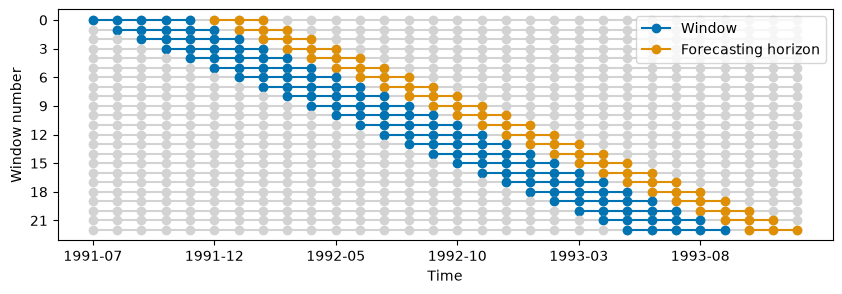

In [55]:
cv = SlidingWindowSplitter(window_length=window_length, fh=fh)
print(f"Число фолдов = {cv.get_n_splits(y)}")
plot_windows(cv, y)

С аргументом `initial_window` первое окно можно сделать больше остальных.

Число фолдов = 18


(<Figure size 1000x300 with 1 Axes>,
 <Axes: xlabel='Time', ylabel='Window number'>)

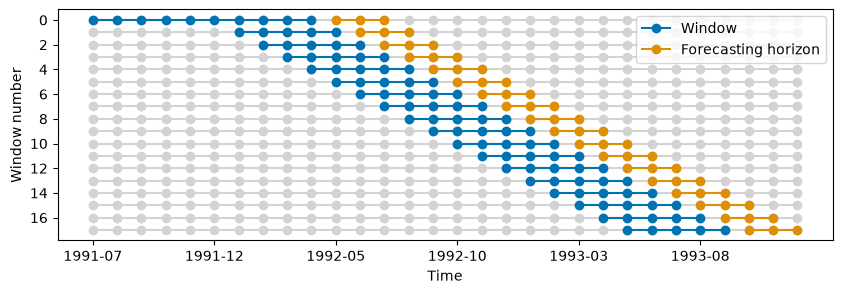

In [58]:
cv = SlidingWindowSplitter(window_length=window_length, fh=fh, initial_window=10)
print(f"Число фолдов = {cv.get_n_splits(y)}")
plot_windows(cv, y)

Также можно в явном виде задать насколько мы сдвигае фолды через `step_length` (часто разумно брать step_length=horizon)

Число фолдов = 6


(<Figure size 1000x300 with 1 Axes>,
 <Axes: xlabel='Time', ylabel='Window number'>)

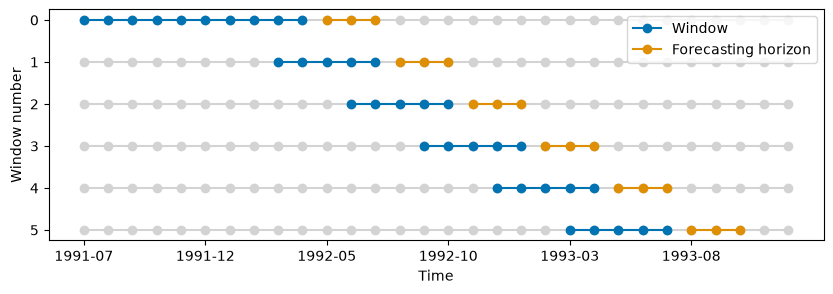

In [66]:
cv = SlidingWindowSplitter(window_length=window_length, step_length=3, fh=fh, initial_window=10)
print(f"Число фолдов = {cv.get_n_splits(y)}")
plot_windows(cv, y)

### `ExpandingWindowSplitter` — расширяющееся окно

Обучающее окно растёт с каждым фолдом (накапливает историю), горизонт постоянен. Это самая частая схема для временных рядов: качество усредняется по нескольким тестовым окнам.

Число фолдов = 23


(<Figure size 1000x300 with 1 Axes>,
 <Axes: xlabel='Time', ylabel='Window number'>)

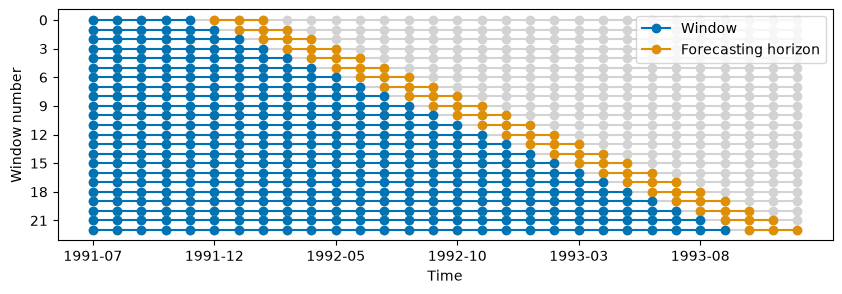

In [60]:
cv = ExpandingWindowSplitter(initial_window=window_length, fh=fh)
print(f"Число фолдов = {cv.get_n_splits(y)}")
plot_windows(cv, y)

### `CutoffSplitter` — заданные точки отсечения

Позволяет вручную указать точки, в которых заканчивается обучающее окно, — удобно, если фолды должны совпадать с конкретными датами (например, концом квартала).

Число фолдов = 4


(<Figure size 1000x300 with 1 Axes>,
 <Axes: xlabel='Time', ylabel='Window number'>)

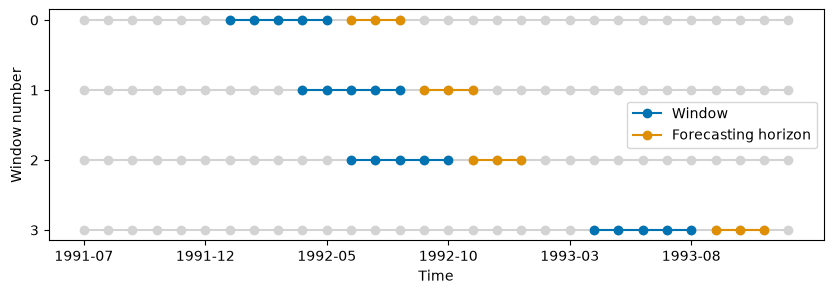

In [67]:
cutoffs = np.array([10, 13, 15, 25])
cv = CutoffSplitter(cutoffs=cutoffs, window_length=window_length, fh=fh)
print(f"Число фолдов = {cv.get_n_splits(y)}")
plot_windows(cv, y)

### От индексов к оценке модели — `evaluate`

Сплиттер сам по себе только режет индексы; обучать и оценивать модель по каждому окну раньше приходилось вручную (как мы делали в разделах 1–2). `sktime.forecasting.model_evaluation.evaluate` берёт это на себя: принимает форекастер и сплиттер, а возвращает готовую таблицу метрик по фолдам. Возьмём весь ряд `a10` и `ExpandingWindowSplitter` на реальном месячном шаге.

In [68]:
cv_full = ExpandingWindowSplitter(initial_window=len(a10) - 24, step_length=6, fh=list(range(1, 7)))
results = evaluate(
    forecaster=NaiveForecaster(strategy="last", sp=12),
    y=a10,
    cv=cv_full,
    strategy="refit",
    return_data=True,
)
results[["test_MeanAbsolutePercentageError", "fit_time", "pred_time", "len_train_window", "cutoff"]]

,test_MeanAbsolutePercentageError,fit_time,pred_time,len_train_window,cutoff
0,0.119653,0.004147,0.028753,180,2006-06
1,0.188673,0.001751,0.010726,186,2006-12
2,0.160086,0.001815,0.009852,192,2007-06
3,0.133526,0.001687,0.008873,198,2007-12


По колонкам: `test_MeanAbsolutePercentageError` — метрика фолда (метрику можно заменить аргументом `scoring`); `len_train_window` — сколько точек попало в обучение в этом фолде (растёт — окно расширяющееся); `cutoff` — последняя обучающая дата фолда; при `return_data=True` в таблице есть ещё `y_train`, `y_test`, `y_pred` — сами ряды и прогнозы для дальнейшего анализа или построения графиков.

🔍 Аргумент `strategy` определяет, что происходит с моделью между фолдами — прямой аналог `refit` в `StatsForecast` и `ETNA`, к которым мы перейдём дальше:

- `"refit"` — модель обучается заново на каждом фолде с нуля (используем выше);
- `"update"` — модель дообучается на новых данных, не переобучаясь полностью (быстрее, поддерживается не всеми форекастерами);
- `"no-update_params"` — параметры модели не меняются вовсе, обновляется только внутреннее состояние (самый быстрый вариант, годится для очень дешёвых моделей вроде наивных).

---
## 4. `StatsForecast`: `cross_validation`

`sktime`-сплиттеры дают индексы окон, а `evaluate` уже прогоняет по ним одну модель. У [`StatsForecast`](https://nixtlaverse.nixtla.com/statsforecast/) вся эта цепочка «нарезать окна → обучить → спрогнозировать → собрать факт рядом с прогнозом» упакована в один метод `cross_validation` — причём сразу для нескольких моделей и (в общем случае) нескольких рядов одновременно.

По умолчанию это **расширяющееся окно** (как `ExpandingWindowSplitter`): обучение накапливает историю, а тестовое окно длиной `h` едет вперёд с шагом `step_size`.

`StatsForecast` ждёт данные в **длинном формате** с колонками `unique_id` (идентификатор ряда), `ds` (дата) и `y` (значение) — подробно этот формат разобран в ноутбуке про знакомство со `StatsForecast` в Семинаре 1; здесь просто приведём `a10` к нему.

In [70]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, SeasonalNaive

sf_df = (
    a10.reset_index()
    .rename(columns={"Month": "ds"})
    .assign(unique_id="a10", ds=lambda d: d["ds"].dt.to_timestamp())[["unique_id", "ds", "y"]]
)
sf_df.head()

,unique_id,ds,y
0,a10,1991-07-01,3.526591
1,a10,1991-08-01,3.180891
2,a10,1991-09-01,3.252221
3,a10,1991-10-01,3.611003
4,a10,1991-11-01,3.565869


Зададим две модели-конкурента — сезонный наивный прогноз (baseline) и `AutoETS` — и запустим кросс-валидацию: горизонт `h=6` месяцев, `n_windows=4` окна, шаг между окнами `step_size=6` (окна не пересекаются).

In [71]:
sf = StatsForecast(
    models=[SeasonalNaive(season_length=12), AutoETS(season_length=12)],
    freq="MS",
)
cv_df = sf.cross_validation(df=sf_df, h=6, n_windows=4, step_size=6)
cv_df.head()

,unique_id,ds,cutoff,y,SeasonalNaive,AutoETS
0,a10,2006-07-01,2006-06-01,16.980282,15.829550,17.615400
1,a10,2006-08-01,2006-06-01,18.612189,17.554701,17.682996
2,a10,2006-09-01,2006-06-01,16.623343,18.100864,17.933473
3,a10,2006-10-01,2006-06-01,21.430241,17.496668,18.994131
4,a10,2006-11-01,2006-06-01,23.575517,19.347265,19.574115


В результате — по строке на каждый прогнозируемый месяц каждого окна:

- 🔍 `cutoff` — точка отсечения: последняя дата, которую модель **видела** при обучении этого окна. Она и разделяет фолды;
- `ds` — дата прогноза (внутри горизонта после `cutoff`);
- `y` — **фактическое** значение (StatsForecast подставляет его сам, вручную склеивать с исходным рядом не нужно);
- `SeasonalNaive`, `AutoETS` — прогнозы моделей.

Четыре значения `cutoff` — это и есть четыре walk-forward окна:

In [72]:
print("Точки отсечения (cutoffs):")
for c in cv_df["cutoff"].unique():
    print(" ", pd.Timestamp(c).date())

Точки отсечения (cutoffs):
  2006-06-01
  2006-12-01
  2007-06-01
  2007-12-01


Нарисуем окна на самом ряде: серым — история, вертикальные линии — `cutoff`, поверх факта наложены прогнозы `AutoETS` в каждом окне.

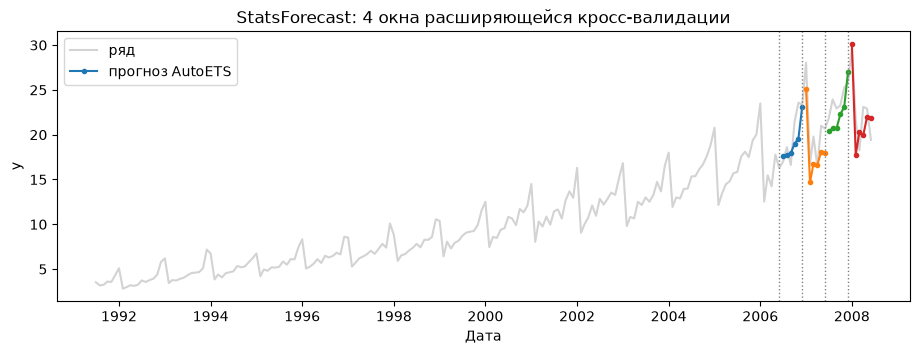

In [73]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(sf_df["ds"], sf_df["y"], color="lightgray", label="ряд")
for i, c in enumerate(cv_df["cutoff"].unique()):
    win = cv_df[cv_df["cutoff"] == c]
    ax.axvline(pd.Timestamp(c), color="gray", ls=":", lw=1)
    ax.plot(
        win["ds"], win["AutoETS"], marker="o", ms=3, label="прогноз AutoETS" if i == 0 else None
    )
ax.legend(loc="upper left")
ax.set(title="StatsForecast: 4 окна расширяющейся кросс-валидации", xlabel="Дата", ylabel="y")
plt.show()

Посчитаем **MAPE** — и по каждому окну отдельно, и суммарно по всем прогнозам. Метрика по окнам показывает разброс качества во времени, агрегированная — итоговую оценку для выбора модели.

In [74]:
def per_window_mape(cv, model):
    """MAPE модели в каждом окне (по cutoff)."""
    g = cv.groupby("cutoff")
    return g.apply(
        lambda w: mean_absolute_percentage_error(w["y"], w[model]),
        include_groups=False,
    )


for model in ["SeasonalNaive", "AutoETS"]:
    per = per_window_mape(cv_df, model)
    overall = mean_absolute_percentage_error(cv_df["y"], cv_df[model])
    print(f"{model:>14}: по окнам = {[f'{v:.1%}' for v in per]}   итого = {overall:.1%}")

 SeasonalNaive: по окнам = ['12.0%', '18.9%', '16.0%', '13.4%']   итого = 15.0%
       AutoETS: по окнам = ['7.7%', '11.1%', '7.9%', '10.2%']   итого = 9.2%


`AutoETS` стабильно точнее сезонного наива во всех окнах — именно на такое сравнение по нескольким тестовым окнам и опираются при выборе модели.

### Скользящее окно и другие параметры

Расширяющееся окно — поведение по умолчанию. Чтобы получить **скользящее** окно фиксированной длины (аналог `SlidingWindowSplitter` или `max_train_size` в `TimeSeriesSplit`), задаётся `input_size` — сколько последних точек брать в обучение:

In [75]:
cv_slide = sf.cross_validation(
    df=sf_df,
    h=6,
    n_windows=4,
    step_size=6,
    input_size=36,
)
print("Скользящее окно (input_size=36), MAPE по моделям:")
for model in ["SeasonalNaive", "AutoETS"]:
    print(f"  {model:>14}: {mean_absolute_percentage_error(cv_slide['y'], cv_slide[model]):.1%}")

Скользящее окно (input_size=36), MAPE по моделям:
   SeasonalNaive: 15.0%
         AutoETS: 9.3%


Ещё пара полезных аргументов `cross_validation`:

- `refit=True` (по умолчанию) — переобучать модель заново в каждом окне; `refit=False` обучает один раз на первом окне и только достраивает прогнозы (быстрее, но менее честно), `refit=k` — переобучать раз в `k` окон;
- `test_size` — задать общий размер теста вместо явного `n_windows` (число окон посчитается из `test_size`, `h` и `step_size`);
- `level=[80, 95]` — вернуть ещё и доверительные интервалы прогноза для каждого окна.

In [76]:
cv_levels = sf.cross_validation(df=sf_df, h=6, n_windows=4, step_size=6, level=[80, 95])
cv_levels.filter(regex="ds|cutoff|AutoETS").head()

,ds,cutoff,AutoETS,AutoETS-lo-95,AutoETS-lo-80,AutoETS-hi-80,AutoETS-hi-95
0,2006-07-01,2006-06-01,17.615400,15.531587,16.252868,18.977933,19.699214
1,2006-08-01,2006-06-01,17.682996,15.599182,16.320463,19.045528,19.766809
2,2006-09-01,2006-06-01,17.933473,15.849659,16.570940,19.296005,20.017286
3,2006-10-01,2006-06-01,18.994131,16.910317,17.631599,20.356664,21.077945
4,2006-11-01,2006-06-01,19.574115,17.490301,18.211582,20.936648,21.657929


---
## 5. `ETNA`: `Pipeline.backtest`

У `ETNA` та же идея walk-forward выражена через собственный контейнер данных (`TSDataset`) и метод `backtest` у пайплайна модели. Это уже третье соглашение об именах колонок в одном ноутбуке — сведём их в таблицу, чтобы не путаться:

| Библиотека | Идентификатор ряда | Время | Значение |
|---|---|---|---|
| `sktime` | (одна `pandas.Series` на ряд) | индекс | значения `Series` |
| `StatsForecast` | `unique_id` | `ds` | `y` |
| `ETNA` | `segment` | `timestamp` | `target` |

In [78]:
from etna.datasets import TSDataset
from etna.metrics import MAE, SMAPE
from etna.models import SeasonalMovingAverageModel
from etna.pipeline import FoldMask, Pipeline

etna_df = (
    a10.reset_index()
    .rename(columns={"Month": "timestamp", "y": "target"})
    .assign(segment="a10", timestamp=lambda d: d["timestamp"].dt.to_timestamp())
)
ts = TSDataset(etna_df, freq="MS")
ts.head()

segment,a10
feature,target
timestamp,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869


🔍 Горизонт прогноза в `ETNA` задаётся не бэктесту, а самому **пайплайну** (`Pipeline(..., horizon=...)`) — в отличие от `h` у `StatsForecast.cross_validation` или `fh` у сплиттеров `sktime`. Возьмём сезонное скользящее среднее (`SeasonalMovingAverageModel`) как baseline и прогоним `backtest` с расширяющимся окном (`mode="expand"`) на 4 фолдах.

In [79]:
pipeline = Pipeline(
    model=SeasonalMovingAverageModel(window=1, seasonality=12),
    transforms=[],
    horizon=6,
)
backtest_result = pipeline.backtest(
    ts=ts,
    metrics=[MAE(), SMAPE()],
    n_folds=4,
    mode="expand",
    n_jobs=1,
    joblib_params={"verbose": 0},
)
list(backtest_result.keys())

['metrics', 'forecasts', 'fold_info', 'pipelines']

`backtest` возвращает словарь из четырёх частей:

- `metrics` — таблица метрик по фолдам и сегментам (аналог таблицы из `per_window_mape` выше);
- `forecasts` — список `TSDataset` с прогнозами по каждому фолду — их можно сразу отрисовать;
- `fold_info` — готовое «расписание» фолдов: даты начала и конца обучения и теста;
- `pipelines` — обученные пайплайны по каждому фолду, если нужно посмотреть на них отдельно.

In [80]:
backtest_result["metrics"]

,segment,MAE,SMAPE,fold_number
0,a10,2.525080,12.752841,0
0,a10,3.817526,20.950453,1
0,a10,3.743189,17.838088,2
0,a10,2.981100,14.642893,3


In [81]:
backtest_result["fold_info"]

,train_start_time,train_end_time,test_start_time,test_end_time,fold_number
0,1991-07-01,2006-06-01,2006-07-01,2006-12-01,0
1,1991-07-01,2006-12-01,2007-01-01,2007-06-01,1
2,1991-07-01,2007-06-01,2007-07-01,2007-12-01,2
3,1991-07-01,2007-12-01,2008-01-01,2008-06-01,3


`fold_info` — то, чего не было в готовом виде ни у `sktime`, ни у `StatsForecast`: явные `train_start_time` / `train_end_time` / `test_start_time` / `test_end_time` на каждый фолд, без необходимости их вычислять по `cutoff` вручную.

### Скользящее окно, шаг и переобучение

Как и раньше, расширяющееся окно (`mode="expand"`) — это накопление истории. Скользящее окно фиксированной длины задаётся `mode="constant"`; шаг между фолдами (аналог `step_size` у `StatsForecast` и `step_length` у `sktime`) — параметром `stride`; частота переобучения — `refit` (снова тот же смысл, что у `strategy` в `sktime.evaluate` и `refit` в `StatsForecast`).

In [82]:
backtest_slide = pipeline.backtest(
    ts=ts,
    metrics=[SMAPE()],
    n_folds=4,
    mode="constant",
    stride=6,
    refit=2,
    n_jobs=1,
    joblib_params={"verbose": 0},
)
backtest_slide["metrics"]

,segment,SMAPE,fold_number
0,a10,12.752841,0
0,a10,20.950453,1
0,a10,17.838088,2
0,a10,14.642893,3


### `FoldMask` — фолды на заданных датах

Если стандартной сетки фолдов недостаточно (нужны конкретные даты отсечения — аналог `CutoffSplitter` у `sktime`), можно описать каждый фолд явной маской: где заканчивается обучение и какие даты прогнозируются.

In [83]:
mask = FoldMask(
    first_train_timestamp=None,
    last_train_timestamp="2007-06-01",
    target_timestamps=pd.date_range("2007-07-01", periods=6, freq="MS"),
)
backtest_mask = pipeline.backtest(
    ts=ts,
    metrics=[SMAPE()],
    n_folds=[mask],
    n_jobs=1,
    joblib_params={"verbose": 0},
)
backtest_mask["fold_info"]

,train_start_time,train_end_time,test_start_time,test_end_time,fold_number
0,1991-07-01,2007-06-01,2007-07-01,2007-12-01,0


---
## Итоги

- Главный принцип валидации временных рядов — **не заглядывать в будущее**: тест всегда позже обучения, данные не перемешиваются.
- Случайное разбиение и `KFold(shuffle=True)` на сериально коррелированных рядах дают **сильно завышенную** оценку качества; на `GOOGL` с горизонтом 20 дней разрыв с честным будущим тестом — впятеро.
- `TimeSeriesSplit` (walk-forward) делит ряд по времени и даёт куда более честную оценку; при прогнозе на горизонт `h > 1` не забывайте про `gap=h-1`, иначе часть утечки остаётся на стыке фолдов.
- `sktime` описывает окна как объекты-сплиттеры (`SingleWindow`, `SlidingWindow`, `ExpandingWindow`, `Cutoff`), а `evaluate` прогоняет через них форекастер и возвращает таблицу метрик — не нужно писать цикл обучения вручную.
- `StatsForecast.cross_validation` и `ETNA Pipeline.backtest` идут дальше: одним вызовом нарезают окна, обучают и оценивают модель (или несколько моделей), возвращая прогнозы рядом с фактом.

Ниже — сопоставление того, как одна и та же идея walk-forward называется в каждом интерфейсе.

| Что настраиваем | sklearn | sktime | StatsForecast | ETNA |
|---|---|---|---|---|
| горизонт прогноза | `test_size` | `fh` | `h` | `horizon` у `Pipeline` |
| число окон | `n_splits` | `initial_window` + `step_length` | `n_windows` | `n_folds` |
| шаг между окнами | — | `step_length` | `step_size` | `stride` |
| расширяющееся окно | по умолчанию | `ExpandingWindowSplitter` | по умолчанию | `mode="expand"` |
| скользящее окно | `max_train_size` | `SlidingWindowSplitter` | `input_size` | `mode="constant"` |
| произвольные точки отсечения | — | `CutoffSplitter` | — | `FoldMask` |
| переобучать ли модель между фолдами | всегда | `strategy=` | `refit=` | `refit=` |
| зазор между train и test | `gap` | — | — | — |
| что возвращает | индексы | таблица метрик (`evaluate`) | таблица прогнозов | словарь из 4 объектов |

Библиотеки различаются не идеей — walk-forward у всех один и тот же, — а тем, **что считается единицей настройки**: индексы (`sklearn`), объект-сплиттер (`sktime`), аргументы одного метода (`StatsForecast`), пайплайн и маски фолдов (`ETNA`).